The tutorial builds a denoising convolutional autoencoder. First, the clean image dataset is loaded, normalized, reshaped, and then artificially corrupted by adding noise. The noisy images are used as input to the model, while the original clean images are used as the target output. The model learns to remove noise by minimizing the difference between its reconstructed output and the clean image. After training, performance is evaluated by comparing noisy images, denoised outputs, and original clean images.

##1. Dataset Preparation and Preprocessing:

• Load the Devnagari dataset using PIL.

• Normalize the images to the range [0, 1].

• Reshape the images to include a channel dimension for Keras Compatibility.

• Split the dataset into training and validation sets.

• Add noise to the images for denoising purposes (Gaussian noise or salt-and-pepper noise).

In [1]:
import zipfile
import os

zip_path = "/content/Copy of devnagari digit (1).zip"
extract_path = "/content/devnagari_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files/folders:")
print(os.listdir(extract_path))

Extracted files/folders:
['DevanagariHandwrittenDigitDataset']


In [2]:
for root, dirs, files in os.walk(extract_path):
    print("Current folder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])
    print("-" * 50)
    break

Current folder: /content/devnagari_dataset
Subfolders: ['DevanagariHandwrittenDigitDataset']
Files: []
--------------------------------------------------


In [3]:
dataset_root = "/content/devnagari_dataset/DevanagariHandwrittenDigitDataset"

print(os.listdir(dataset_root))

['Train', 'Test']


In [4]:
for root, dirs, files in os.walk(dataset_root):
    print("Current folder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])
    print("-" * 50)

Current folder: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset
Subfolders: ['Train', 'Test']
Files: []
--------------------------------------------------
Current folder: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train
Subfolders: ['digit_8', 'digit_9', 'digit_6', 'digit_0', 'digit_5', 'digit_1', 'digit_3', 'digit_7', 'digit_4', 'digit_2']
Files: []
--------------------------------------------------
Current folder: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train/digit_8
Subfolders: []
Files: ['53260.png', '78925.png', '99343.png', '42117.png', '78853.png', '78842.png', '78676.png', '99424.png', '78899.png', '91651.png']
--------------------------------------------------
Current folder: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train/digit_9
Subfolders: []
Files: ['68504.png', '86632.png', '30696.png', '42520.png', '7364.png', '50115.png', '7510.png', '42325.png', '68699.png', '99442.png']
----------------------------

##Load dataset

• Reshape the images to include a channel dimension for Keras Compatibility.

• Split the dataset into training and validation sets.

In [5]:
import tensorflow as tf

train_dir = "/content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test"

img_size = (28, 28)
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode=None,  # IMPORTANT → autoencoder doesn’t need labels
    image_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode=None,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

Found 17000 files.
Found 3000 files.


##Normalize the images to the range [0, 1]

In [6]:
def normalize(image):
    return image / 255.0

train_dataset = train_dataset.map(lambda x: normalize(x))
test_dataset = test_dataset.map(lambda x: normalize(x))



##Add noise to the images for denoising purposes

In [7]:
import tensorflow as tf

noise_factor = 0.5

def add_noise(image):
    noise = noise_factor * tf.random.normal(shape=tf.shape(image))
    noisy_image = image + noise
    noisy_image = tf.clip_by_value(noisy_image, 0.0, 1.0)
    return noisy_image, image

In [8]:
train_noisy_dataset = train_dataset.map(add_noise)
test_noisy_dataset = test_dataset.map(add_noise)

#Step 2: Build Denoising Convolutional Autoencoder

In [9]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [10]:
def build_denoising_autoencoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape)

    # Encoder: compress image
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder: reconstruct image
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder

In [11]:
autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

#Step 3 : Train the Denoising Autoencoder:

In [12]:
history = autoencoder.fit(
    train_noisy_dataset,
    epochs=10,
    validation_data=test_noisy_dataset
)

Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - loss: 0.2398 - val_loss: 0.2082
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - loss: 0.2062 - val_loss: 0.2079
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.2020 - val_loss: 0.1996
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - loss: 0.1999 - val_loss: 0.1991
Epoch 5/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - loss: 0.1984 - val_loss: 0.1968
Epoch 6/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - loss: 0.1972 - val_loss: 0.1961
Epoch 7/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 43s 75ms/step - loss: 0.1963 - val_loss: 0.1959
Epoch 8/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - loss: 0.1955 - val_loss: 0.1946
Epoch 9/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - loss: 0.1946 - val_loss: 0.1941
Epoch 10/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - loss: 0.1943 - val_loss: 0.1950


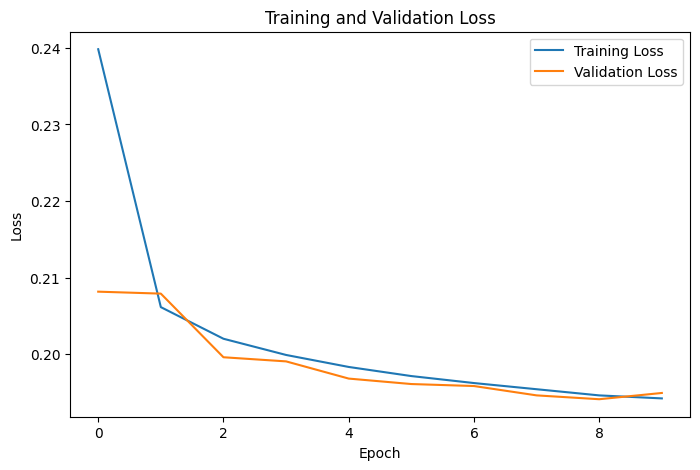

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

#Step 4: Evaluate and Visualize

In [15]:
# Get one batch from test dataset
noisy_images, clean_images = next(iter(test_noisy_dataset))

# Predict denoised images
denoised_images = autoencoder.predict(noisy_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


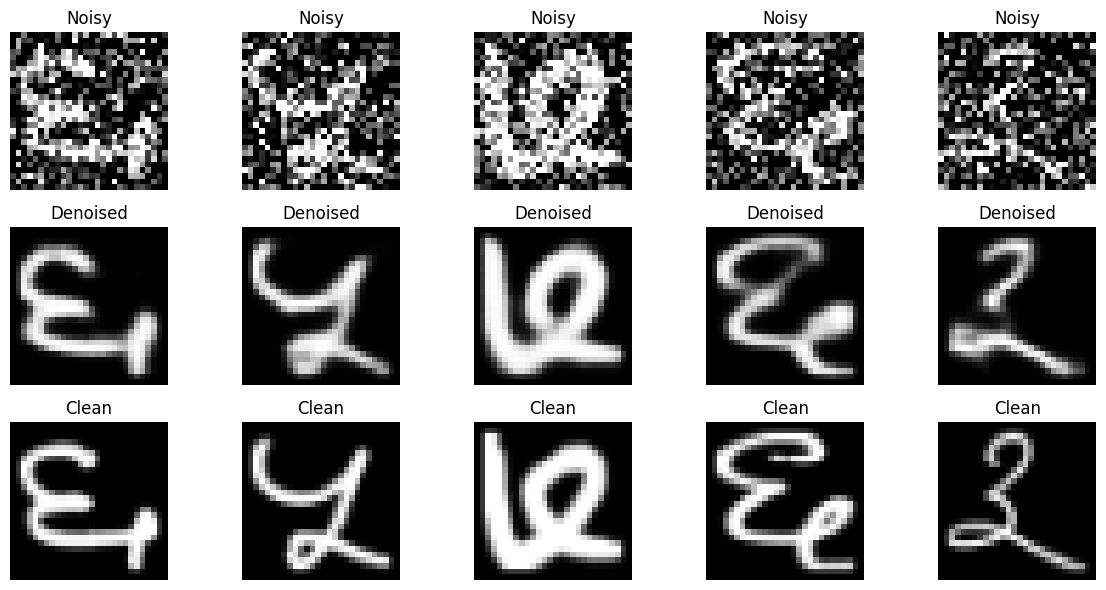

In [16]:
import matplotlib.pyplot as plt

n = 5  # number of images to show

plt.figure(figsize=(12, 6))

for i in range(n):
    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].numpy().reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Clean
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(clean_images[i].numpy().reshape(28, 28), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

plt.tight_layout()
plt.show()

 ##Experiment and Fine - Tune the Model

In [17]:
import tensorflow as tf

noise_factor = 0.6

def add_noise(image):
    noise = noise_factor * tf.random.normal(shape=tf.shape(image))
    noisy_image = image + noise
    noisy_image = tf.clip_by_value(noisy_image, 0.0, 1.0)
    return noisy_image, image

In [18]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [19]:
def build_denoising_autoencoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape)

    # Encoder: compress image
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder: reconstruct image
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder

In [20]:
autoencoder = build_denoising_autoencoder()

In [21]:
history = autoencoder.fit(
    train_noisy_dataset,
    epochs=13,
    validation_data=test_noisy_dataset
)

Epoch 1/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 66s 121ms/step - loss: 0.2348 - val_loss: 0.2059
Epoch 2/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 66s 125ms/step - loss: 0.2017 - val_loss: 0.2003
Epoch 3/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 78s 118ms/step - loss: 0.1979 - val_loss: 0.1962
Epoch 4/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 85s 123ms/step - loss: 0.1957 - val_loss: 0.1949
Epoch 5/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 81s 121ms/step - loss: 0.1943 - val_loss: 0.1928
Epoch 6/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 63s 119ms/step - loss: 0.1932 - val_loss: 0.1927
Epoch 7/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 63s 119ms/step - loss: 0.1923 - val_loss: 0.1917
Epoch 8/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - loss: 0.1914 - val_loss: 0.1926
Epoch 9/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 85s 123ms/step - loss: 0.1908 - val_loss: 0.1902
Epoch 10/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 81s 122ms/step - loss: 0.1904 - val_loss: 0.1896
Epoch 11/13
532/532 ━━━━━━━━━━━━━━━━━━━━ 63s 119ms/step - loss: 0.1898 - val_loss: 0.1918
Epoch 12/13
532/532

In this experiment, the model architecture and training parameters were modified to improve performance. The noise factor was increased from 0.5 to 0.6, making the denoising task more challenging. Additionally, an extra convolutional layer was added to the encoder, increasing the model’s depth and capacity to learn complex features. The number of training epochs was also increased from 10 to 13.

The results show that the modified model achieved lower training and validation loss compared to the original model. The validation loss decreased from approximately 0.195 to 0.188, indicating improved generalization. Despite the increased noise level, the deeper architecture was able to better reconstruct the clean images, demonstrating that increasing model capacity can enhance performance.

Overall, the experiment shows that increasing the depth of the network and training duration leads to better denoising performance, even under more challenging noise conditions.